In [2]:
import sys

import pandas as pd
import numpy as np
import random
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import tigramite
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.data_processing import DataFrame
from tigramite.plotting import plot_graph
from statsmodels.tsa.stattools import adfuller
from tigramite.independence_tests.parcorr import ParCorr
import warnings
import os
import numpy as np
import json
import tigramite.plotting as tp
import matplotlib.pyplot as plt
from pathlib import Path
import networkx as nx
from matplotlib.colors import LinearSegmentedColormap
import tigramite.plotting as tp
import copy

warnings.filterwarnings('ignore', category=FutureWarning)
sys.path.append('../')

In [3]:
# Ensure the folder exists
folder_path = 'visual'
os.makedirs(folder_path, exist_ok=True)
save_type = ".eps"
dpi = 500

In [4]:
current_path = Path(__file__).resolve().parent if '__file__' in globals() else Path().resolve()
path = current_path.parent / "data" / "gold" / "experiment_1" / "exp_36_minidc_prepared__df_exp_1__f1_g1"


In [5]:
df_raw = pd.read_parquet(path / "graph_generator.parquet")

df_raw

,time,cpu_temp_1,cpu_temp_2,env_humidity,env_pressure,env_temp,dc_fan,dc_pump,house_fan,house_pump,stress_ctrl,water_temp_house,water_temp_in_HEX,water_temp_out_HEX
0,2025-05-06 07:09:50,54.05,49.90,35.031152,1006.353467,22.279479,0.0,0.0,100.0,100.0,0.0,19.484568,19.964573,20.240701
1,2025-05-06 07:09:55,52.95,51.30,35.039597,1006.354410,22.280195,0.0,0.0,100.0,100.0,0.0,19.542520,19.940734,20.249073
2,2025-05-06 07:10:00,53.50,49.90,35.047966,1006.354243,22.280098,0.0,0.0,100.0,100.0,0.0,19.276588,19.977639,20.229968
3,2025-05-06 07:10:05,52.70,50.75,35.059175,1006.358330,22.280488,0.0,0.0,100.0,100.0,0.0,18.978240,19.925457,20.230269
4,2025-05-06 07:10:10,52.95,50.75,35.057132,1006.369564,22.278568,0.0,0.0,100.0,100.0,0.0,18.738357,19.937460,20.235376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5162,2025-05-06 14:25:05,30.10,30.40,30.809488,1004.844255,24.825410,0.0,0.0,100.0,100.0,0.0,22.647774,22.751290,22.590685
5163,2025-05-06 14:25:10,32.35,29.30,30.774621,1004.844799,24.831758,0.0,0.0,100.0,100.0,0.0,22.607054,22.734776,22.590822
5164,2025-05-06 14:25:15,32.85,29.30,30.788851,1004.849941,24.838789,0.0,0.0,100.0,100.0,0.0,22.571351,22.701502,22.604002
5165,2025-05-06 14:25:20,31.75,29.05,30.835040,1004.854589,24.847708,0.0,0.0,100.0,100.0,0.0,22.655311,22.780664,22.570150


In [6]:
def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna(), autolag='AIC')
    p_value = result[1]
    return p_value < 0.01  # If p-value is less than 0.01, the series is stationary

# Function to make the series stationary
def make_stationary(df, max_diff=1):

    """
    Transforms the columns of a DataFrame to be stationary using iterative differencing.

    For each column in the input DataFrame, this function:
    - Includes columns with constant values as-is (since they are stationary).
    - Checks if the series is already stationary via `check_stationarity()`; if so, includes as-is.
    - Otherwise, applies differencing up to `max_diff` times, stopping if the series becomes stationary.
    - Includes the resulting stationary series (if any) in the output DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with time series columns to be made stationary.
    max_diff : int, default=1
        Maximum number of differencing steps to attempt for each column.

    Returns
    -------
    stationary_df : pd.DataFrame
        DataFrame containing transformed stationary columns (possibly with fewer rows due to differencing).
        Columns that are constant are included as-is.

    Notes
    -----
    - Requires the function `check_stationarity(series)` to be defined elsewhere; this should return True if the input series is stationary.
    - The output may have missing values at the beginning of each column due to differencing, which are retained as NaN or may be trimmed by dropna.

    Examples
    --------
    >>> stationary_df = make_stationary(df, max_diff=2)
    """
    stationary_df = pd.DataFrame()
    
    # Check stationarity of each column
    for column in df.columns:
        series = df[column].dropna()
        
        # Check if the series is constant
        # Constant columns are included as-is (they are stationary)
        if series.nunique() == 1:
            stationary_df[column] = series
            continue
        
        # Check if the series is already stationary
        if check_stationarity(series):
            stationary_df[column] = series
            continue
        
        differenced_series = series.copy()
        
        # Apply differencing up to max_diff times
        for d in range(1, max_diff + 1):
            differenced_series = differenced_series.diff().dropna()
            if check_stationarity(differenced_series):
                break
        
        # Store the stationary series in the DataFrame
        stationary_df[column] = differenced_series
    
    return stationary_df

df_raw = pd.read_parquet(path / "graph_generator.parquet")


df = df_raw.drop(columns="time")

var_names = df.columns.tolist()

df = make_stationary(df)

(<Figure size 1200x900 with 1 Axes>, <Axes: >)

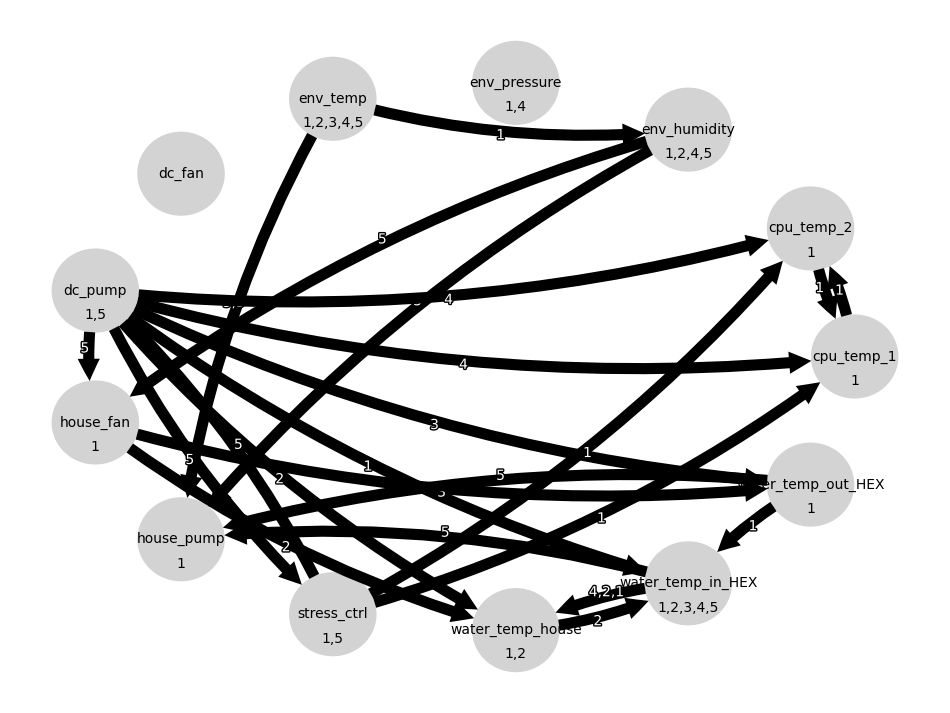

In [7]:
tau_max = 5
alpha = 0.01
tau_min = 1


df_raw = pd.read_parquet(path / "graph_generator.parquet")


df = df_raw.drop(columns="time")

df = make_stationary(df)

var_names = df.columns.tolist()

df = df.dropna()

# Original PCMCI/PC code
df_tri = pp.DataFrame(df.to_numpy(), var_names=var_names)
parcorr = ParCorr()
pcmci = PCMCI(
dataframe=df_tri,
cond_ind_test=parcorr,
verbosity=0
)

results = pcmci.run_pcalg(tau_min=tau_min, tau_max=tau_max, pc_alpha=alpha)

p_matrix = results['p_matrix']

graph = pcmci.get_graph_from_pmatrix(p_matrix=p_matrix, alpha_level=alpha, tau_min=tau_min, tau_max=tau_max, link_assumptions=None)
results['graph'] = graph

tp.plot_graph(
    graph=graph,
    var_names=var_names,
    show_autodependency_lags=True,
    cmap_edges="#333333",
    figsize=(12, 9),
    curved_radius=-0.1
)

In [8]:


# make a deep copy of the object
val_matrix = copy.deepcopy(results['val_matrix'])
graph = copy.deepcopy(results['graph'])

val_matrix

array([[[ 0.00000000e+00,  4.47583517e-01,  1.74411616e-02,
         -1.82393489e-02, -5.69588553e-03, -2.23878691e-02],
        [ 0.00000000e+00,  2.16756029e-01, -1.74535295e-02,
         -3.56764854e-02, -2.61459115e-02, -3.02895530e-02],
        [ 0.00000000e+00,  1.96891554e-02,  1.68719468e-02,
          1.37437227e-02,  1.96407637e-02,  2.45856535e-02],
        ...,
        [ 0.00000000e+00,  1.37674199e-02,  2.15383373e-02,
          1.80518182e-02,  9.03608719e-03,  2.66063456e-03],
        [ 0.00000000e+00,  2.94927963e-02,  1.11284733e-02,
          1.38737325e-02,  5.64306492e-03,  5.97667094e-03],
        [ 0.00000000e+00,  8.50057022e-03,  7.11493616e-03,
          1.04866650e-02,  3.80904802e-03, -1.81315513e-03]],

       [[ 0.00000000e+00,  3.44764692e-01,  2.64947004e-02,
         -1.14913738e-02, -3.44312503e-02, -2.92310926e-02],
        [ 0.00000000e+00,  5.47885052e-01, -1.43286177e-02,
          2.65584045e-02, -1.71179525e-02,  2.81822840e-03],
        [ 0.00000

In [9]:
for i, name in enumerate(var_names):
    print(f"{i}: {name}")

0: cpu_temp_1
1: cpu_temp_2
2: env_humidity
3: env_pressure
4: env_temp
5: dc_fan
6: dc_pump
7: house_fan
8: house_pump
9: stress_ctrl
10: water_temp_house
11: water_temp_in_HEX
12: water_temp_out_HEX


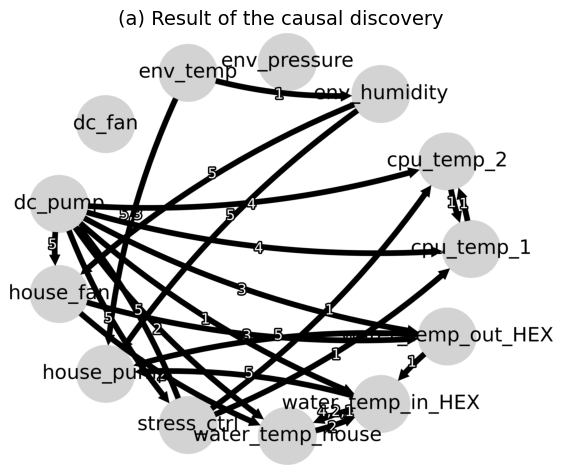

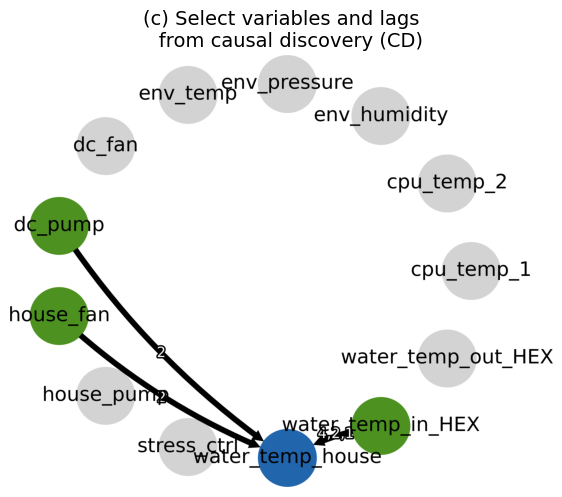

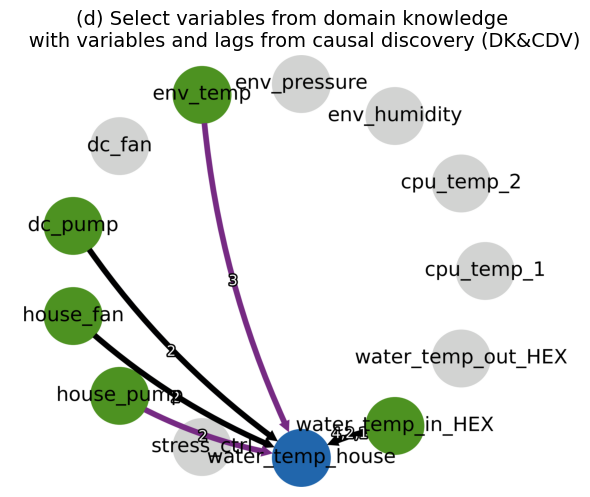

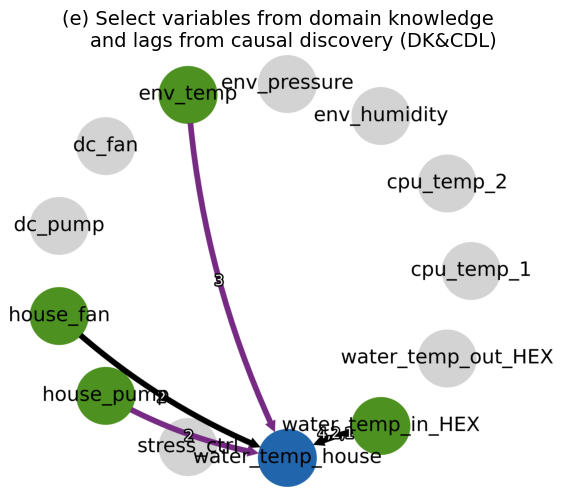

In [16]:


# === PCMCI results ===
graph = pcmci.get_graph_from_pmatrix(
    p_matrix=p_matrix,
    alpha_level=alpha,
    tau_min=tau_min,
    tau_max=tau_max,
    link_assumptions=None,
)
results['graph'] = graph

# === Colormaps ===
# cmap_nodes = LinearSegmentedColormap.from_list(
#     "EmeraldNavy", ["#4d9221", "lightgrey", "#2166ac"]
# )
cmap_nodes = LinearSegmentedColormap.from_list(
    "EmeraldNavy", ["#2166ac", "lightgrey", "#4d9221"]
)
cmap_edges = LinearSegmentedColormap.from_list(
    "EdgeMap", ["#b2182b", "black", "#762a83"]
)

# === Prepare filtered graph ===
target_var = "water_temp_house"
target_idx = var_names.index(target_var)
graph_incoming = np.zeros_like(graph, dtype=object)
graph_incoming[:, target_idx, :] = graph[:, target_idx, :]
val_matrix = np.zeros_like(graph_incoming, dtype=float)

# --- helper: render Tigramite plot to cropped numpy image ---
def render_graph_to_image(graph_to_plot, val_matrix=None, dpi=dpi):
    """Render Tigramite graph at high DPI and crop whitespace"""
    fig, ax = tp.plot_graph(
        graph=graph_to_plot,
        val_matrix=val_matrix,
        var_names=var_names,
        show_autodependency_lags=False,
        cmap_nodes=cmap_nodes,
        cmap_edges=cmap_edges,
        show_colorbar=False,
        figsize=(6.5, 6),
        arrow_linewidth=4,
        curved_radius=-0.1,
        node_label_size=14,
        link_label_fontsize=None,
    )
    fig.set_dpi(dpi)
    fig.canvas.draw()
    # Updated: Use buffer_rgba() for RGBA, reshape to (4,), then slice to RGB
    img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    img = img[:, :, :3]  # Drop alpha channel to get RGB
    plt.close(fig)

    # ---- crop white borders automatically ----
    gray = img.mean(axis=-1)
    mask = gray < 250  # keep only non-white
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    cropped = img[y0:y1, x0:x1]
    return cropped

# === Collect 4 visuals ===
images = []
titles = [
    "(a) Result of the causal discovery",
    "(c) Select variables and lags\n   from causal discovery (CD)",
    "(d) Select variables from domain knowledge \n   with variables and lags from causal discovery (DK&CDV)",
    "(e) Select variables from domain knowledge \n    and lags from causal discovery (DK&CDL)"
]

# 1. Full original graph
images.append(render_graph_to_image(graph))
#images.append(render_graph_to_image(graph))

['cpu_temp_1', 'cpu_temp_2', 'env_humidity', 'env_pressure','env_temp',
 'dc_fan', 'dc_pump', 'house_fan', 'house_pump','stress_ctrl',
 'water_temp_house', 'water_temp_in_HEX', 'water_temp_out_HEX']

# 2. Only incoming links to target
for var in [6, 7, 11]:
    graph_incoming[var, var, 1] = '-->'
    val_matrix[var, var, 1] = 1.0
graph_incoming[target_idx, target_idx, 1] = '-->'
val_matrix[target_idx, target_idx, 1] = -1.0
images.append(render_graph_to_image(graph_incoming, val_matrix))

# 3. Add additional missing links

graph_incoming[4, 4, 1] = '-->'
val_matrix[4, 4, 1] = 1.0
graph_incoming[4, target_idx, 3] = '-->'
val_matrix[4, target_idx, 3] = 1.0
graph_incoming[8, target_idx, 2] = '-->'
val_matrix[8, target_idx, 2] = 1.0

for var in [6, 7, 11, 4, 8]:
    graph_incoming[var, var, 1] = '-->'
    val_matrix[var, var, 1] = 1.0
images.append(render_graph_to_image(graph_incoming, val_matrix))

graph_incoming[6, target_idx, 2] = ''
val_matrix[6, target_idx, 2] = 0#

for var in [6]:
    graph_incoming[var, var, 1] = '-->'
    val_matrix[var, var, 1] = 0
images.append(render_graph_to_image(graph_incoming, val_matrix))

# === Display and save each figure separately ===
for i, (img, title) in enumerate(zip(images, titles), 1):
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.title(title, fontsize=14)
    plt.axis("off")
    filename = os.path.join(folder_path, f'causal_discovery_domain_2_{i}.svg')
    plt.savefig(filename, bbox_inches='tight', pad_inches=0.2, dpi=dpi)
    plt.show()

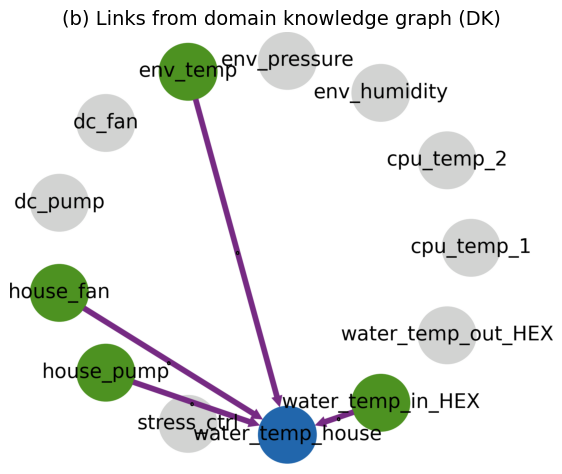

In [33]:


# === PCMCI results ===
graph = pcmci.get_graph_from_pmatrix(
    p_matrix=p_matrix,
    alpha_level=alpha,
    tau_min=tau_min,
    tau_max=tau_max,
    link_assumptions=None,
)
results["graph"] = graph

# === Colormaps ===
# keep node colormap normal
cmap_nodes = LinearSegmentedColormap.from_list(
    "EmeraldNavy",["#2166ac", "lightgrey", "#4d9221"]
)

# --- Violet-colored edges using hex "#762a83"
cmap_edges = LinearSegmentedColormap.from_list(
    "EdgeMapViolet", ["#762a83", "#762a83"]
)

# === Prepare human knowledge graph ===
target_var = "water_temp_house"
target_idx = var_names.index(target_var)
graph_human = np.zeros_like(graph, dtype=object)
val_human = np.zeros_like(graph_human, dtype=float)

links_human = {
    "water_temp_house": [
        ["water_temp_house", -1],
        ["house_fan", -1],
        ["water_temp_in_HEX", -1],
        ["env_temp", -1],
        ["house_pump", -1],
    ]
}

for cause, lag_info in links_human["water_temp_house"]:
    if cause in var_names:
        cause_idx = var_names.index(cause)
        lag = abs(lag_info)
        graph_human[cause_idx, target_idx, lag] = "-->"
        val_human[cause_idx, target_idx, lag] = -1.0

        graph_human[cause_idx, cause_idx, lag] = "-->"
        val_human[cause_idx, cause_idx, lag] = 1

    graph_human[target_idx, target_idx, lag] = "-->"
    val_human[target_idx, target_idx, lag] = -1

# --- Helper: render Tigramite plot to cropped numpy image ---
def render_graph_to_image(graph_to_plot, dpi=300):
    """Render Tigramite graph at high DPI and crop whitespace."""

    # Create dummy val_matrix so cmap_edges applies the violet color
    val_matrix = val_human#np.ones_like(graph_to_plot, dtype=float)

    fig, ax = tp.plot_graph(
        graph=graph_to_plot,
        val_matrix=val_matrix,  # ensures the edge colormap is used
        var_names=var_names,
        show_autodependency_lags=False,
        cmap_nodes=cmap_nodes,
        cmap_edges=cmap_edges,  # violet color
        show_colorbar=False,
        figsize=(6.5, 6),
        arrow_linewidth=4,
        curved_radius=-0,
        node_label_size=14,
        link_label_fontsize=0.000000001
    )

    fig.set_dpi(dpi)
    fig.canvas.draw()

    # Convert figure to numpy array
    img = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    img = img[:, :, :3]
    plt.close(fig)

    # ---- crop white borders automatically ----
    gray = img.mean(axis=-1)
    mask = gray < 250
    if np.any(mask):
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        cropped = img[y0:y1, x0:x1]
        return cropped
    return img

# === Render and show only the human knowledge graph (violet edges, no numbers) ===
image = render_graph_to_image(graph_human)

plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.title("(b) Links from domain knowledge graph (DK)", fontsize=14)
plt.axis("off")

figure_filename = os.path.join(folder_path, "causal_discovery_domain_2_0" + '.svg')
plt.savefig(figure_filename, bbox_inches="tight", pad_inches=0.2, dpi=dpi)
plt.show()

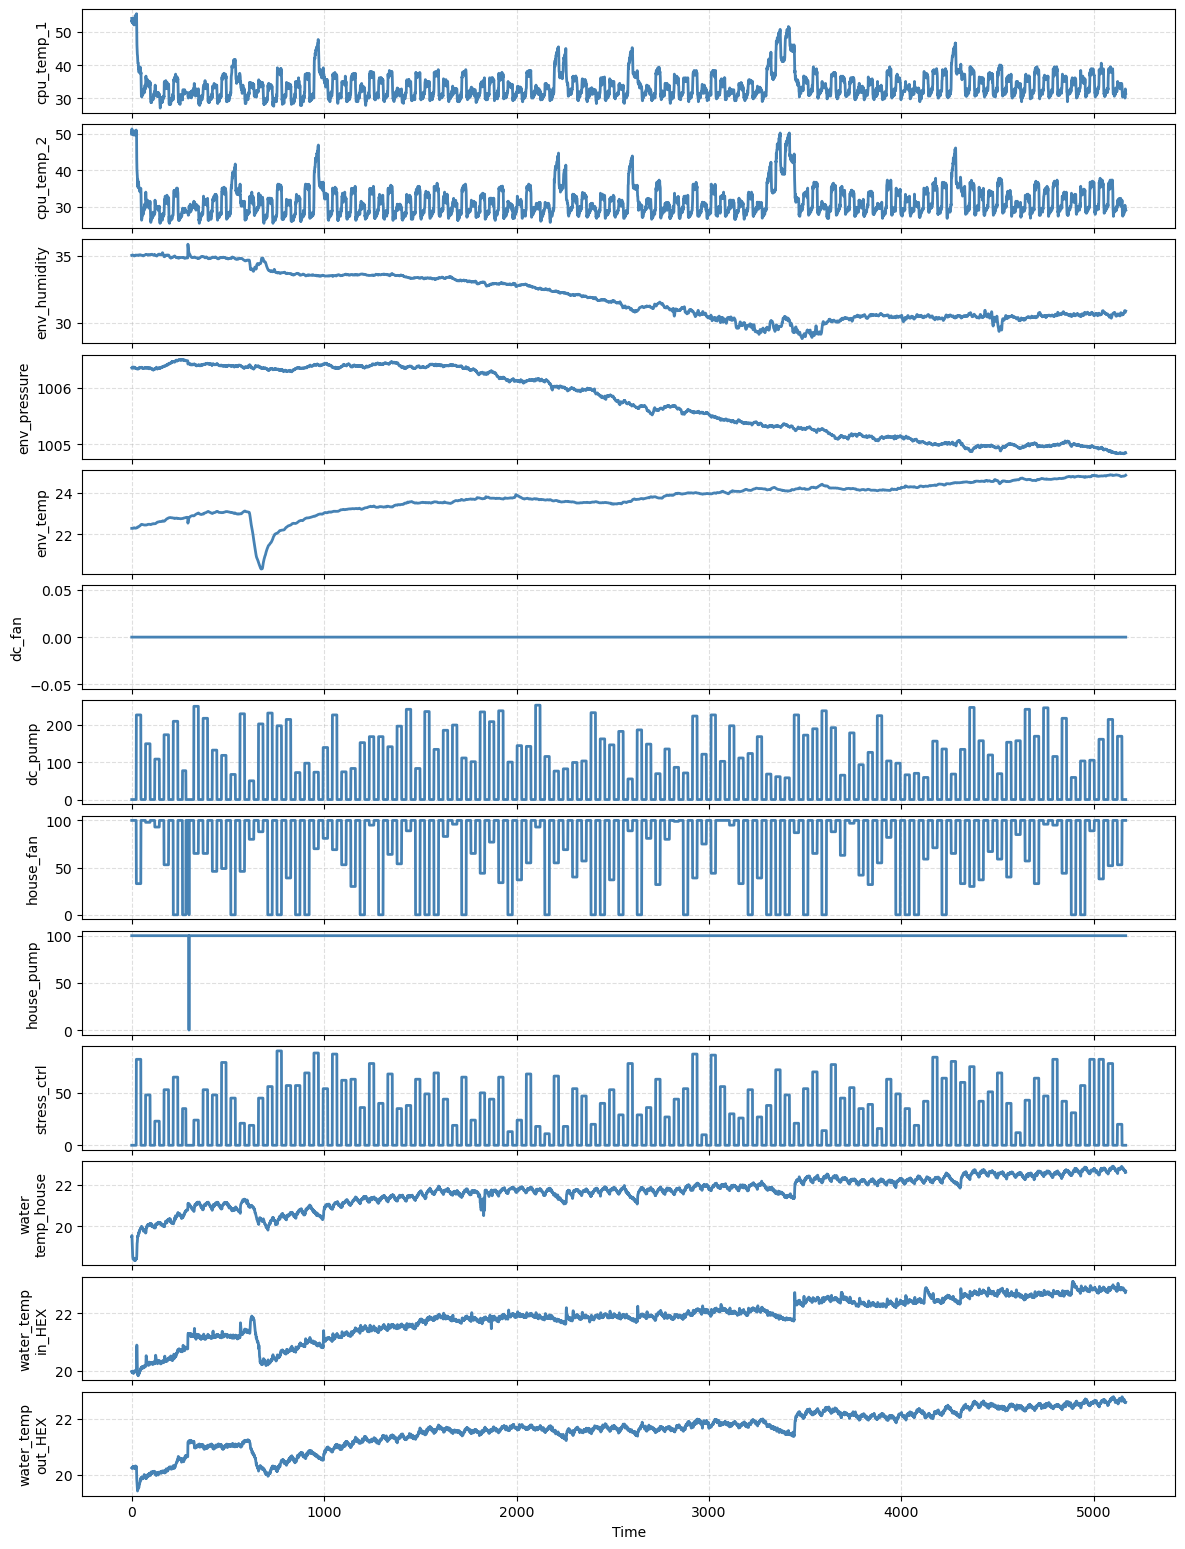

In [63]:


# Prepare data (assuming df_raw is already loaded)
df = df_raw.dropna().drop(columns="time")

# Function to split long variable names into two lines
def split_name(name, maxlen=14):
    parts = name.split('_')
    if len(name) <= maxlen or len(parts) == 1:
        return name
    # Try to split at the middle underscore
    mid = len(parts) // 2
    return '_'.join(parts[:mid]) + '\n' + '_'.join(parts[mid:])

# Apply the split_name function to all columns for y-labels
ylabels = [split_name(col) for col in df.columns]

# Plot: Each variable as a separate subplot, all lines in medium blue, moderate y-axis height
fig, axes = plt.subplots(df.shape[1], 1, figsize=(12, 1.2 * df.shape[1]), sharex=True)

if df.shape[1] == 1:
    axes = [axes]  # Ensure axes is iterable

for i, (col, ylabel) in enumerate(zip(df.columns, ylabels)):
    ax = axes[i]
    sns.lineplot(data=df, x=df.index, y=col, ax=ax, color='#4682b4', linewidth=2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Time' if i == df.shape[1] - 1 else '')
    ax.grid(True, linestyle='--', alpha=0.4)
    if i != df.shape[1] - 1:
        ax.set_xlabel('')
    ax.set_title("")  # Remove subplot titles for compactness

plt.tight_layout(h_pad=0.2)
plt.show()

# Background visuals for paper

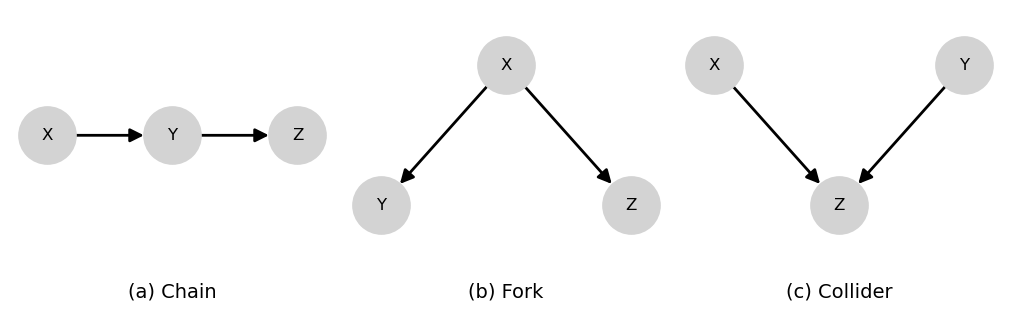

In [64]:


def draw_custom_graph(ax, edges, positions, label):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    nx.draw(
        G, pos=positions, ax=ax,
        with_labels=True,
        node_size=1700,
        node_color='lightgray',
        edge_color='black',
        arrows=True,
        arrowsize=20,
        width=2,
        font_size=12
    )
    ax.text(0.5, -0.12, label, fontsize=14, ha='center', va='center', transform=ax.transAxes)
    ax.set_xlim(-0.3, 2.3)
    ax.set_ylim(-0.4, 1.4)   # <-- more space below
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)

# (a) Chain: X → Y → Z (centered vertically)
edges_chain = [('X', 'Y'), ('Y', 'Z')]
pos_chain = {'X': (0, 0.5), 'Y': (1, 0.5), 'Z': (2, 0.5)}
draw_custom_graph(axes[0], edges_chain, pos_chain, '(a) Chain')

# (b) Fork: Y ← X → Z (inverted V)
edges_fork = [('X', 'Y'), ('X', 'Z')]
pos_fork = {'Y': (0, 0), 'X': (1, 1.0), 'Z': (2, 0)}
draw_custom_graph(axes[1], edges_fork, pos_fork, '(b) Fork')

# (c) Collider: X → Z ← Y (downward V)
edges_collider = [('X', 'Z'), ('Y', 'Z')]
pos_collider = {'X': (0, 1.0), 'Y': (2, 1.0), 'Z': (1, 0)}
draw_custom_graph(axes[2], edges_collider, pos_collider, '(c) Collider')



figure_filename = os.path.join(folder_path, 'causal_links' + save_type)
plt.savefig(figure_filename, bbox_inches='tight', pad_inches=0.2, dpi=dpi)
plt.show()


In [65]:
 
graph = np.array([[
        ['', '-->', ''],
        ['', '-->', ''],
        ['', '', '-->']],

       [['', '', ''],
        ['', '-->', ''],
        ['', '', '']],

       [['', '', '-->'],
        ['', '', '-->'],
        ['', '-->', '']]])

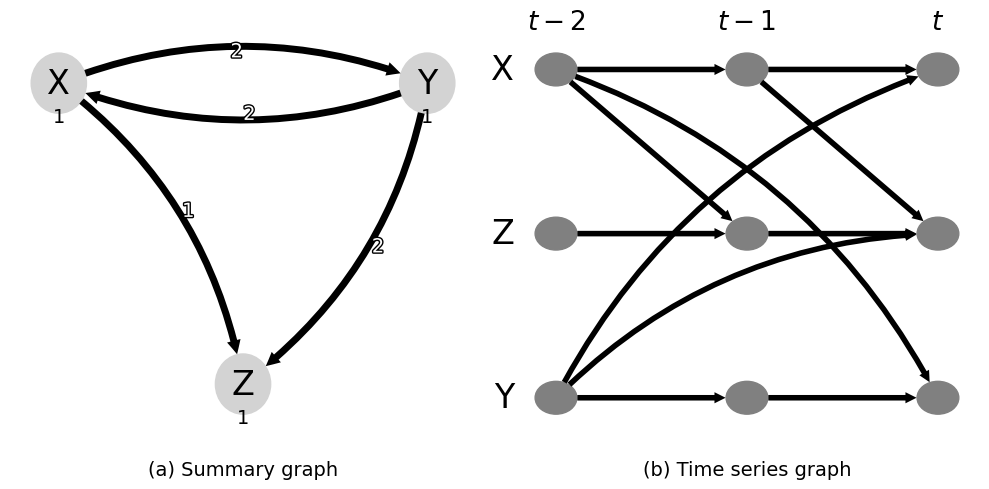

In [66]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))

# Positions of nodes for process graph
node_pos =  {
            'y': np.array([0.5, 0., 0.5, 1.]),
            'x': np.array([0., 0.5, 1., .5])
            }

var_names = ['X', 'Z', 'Y']

tp.plot_graph(
    fig_ax = (fig, axes[0]),
    graph = graph,
    node_pos=node_pos,
    arrow_linewidth=5,
    node_size=0.1,
    node_aspect=1.5,
    var_names=var_names,
    #tick_label_size=12,
    link_label_fontsize=14, 
    label_fontsize=24,
    node_label_size=24,
    #standard_color_nodes='grey',
    show_autodependency_lags = True
    )
axes[0].set_xlabel('(a) Summary graph', fontsize=14, labelpad=20)

special_nodes = {}

# for node in {(1, 3)}:
#     special_nodes[node] = 'red'
# for node in {(1, 2)}:
#     special_nodes[node] = 'blue'
# for node in {(1, 1)}:
#     special_nodes[node] = 'blue'
# for node in {(0, -1)}:
#     special_nodes[node] = 'blue'
# for node in {(0, -2)}:
#     special_nodes[node] = 'blue'


tp.plot_time_series_graph(
    fig_ax = (fig, axes[1]),
    graph = graph,
    var_names=var_names, 
    #special_nodes=special_nodes,
    standard_color_nodes='grey',
    tick_label_size=12,
    label_fontsize=24
    #standard_color_links='black'
    )


axes[1].set_xlabel('(b) Time series graph', fontsize=14, labelpad=20)

fig.tight_layout()

# Save the figure
figure_filename = os.path.join(folder_path, 'time_series_graph'+ save_type)
plt.savefig(figure_filename, bbox_inches='tight', pad_inches=0.2)

In [67]:
graph = np.array([[['', '-->', ''],
        ['', '-->', ''],
        ['', '-->', '']],

       [['', '', ''],
        ['', '-->', ''],
        ['', '', '']],

       [['', '', '-->'],
        ['', '', '-->'],
        ['', '-->', '']]])

In [68]:


def plot_incoming_arrows(graph, target_variable, var_names=None, node_size=300, 
                         node_color='lightblue', target_node_color='red', 
                         highlight_color='darkblue', arrow_color='black', 
                         arrow_size=10, title='', ax=None, min_lag=-2):
    n_variables = len(var_names) if var_names is not None else len(graph)
    
    # Always show lag t (lag=0) and t-1
    min_lag = min_lag
    max_lag = 0
    
    if var_names is None:
        var_names = [f'Var{i}' for i in range(n_variables)]
    
    G = nx.DiGraph()
    
    for i, var in enumerate(var_names):
        for lag in range(min_lag, max_lag+1):
            G.add_node((i, lag))
    
    if target_variable in graph:
        for source_var, lag in graph[target_variable]:
            G.add_edge((source_var, lag), (target_variable, 0))
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))  # Smaller/compact figure size
    else:
        fig = ax.figure
    
    # More compact positioning
    horiz_scale = 0.8
    vert_scale = 0.8
    pos = {(i, lag): ((lag - min_lag) * horiz_scale, -i * vert_scale)
           for i in range(n_variables) for lag in range(min_lag, max_lag+1)}
    
    highlight_set = set((source_var, lag) for source_var, lag in graph.get(target_variable, []))
    node_colors = [
        highlight_color if (i, lag) in highlight_set
        else node_color if (i, lag) != (target_variable, 0) 
        else target_node_color
        for i in range(n_variables) for lag in range(min_lag, max_lag+1)
    ]
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, ax=ax)
    
    # Draw edges
    all_edges = list(G.edges())
    nx.draw_networkx_edges(G, pos, edgelist=all_edges, edge_color=arrow_color, 
                           connectionstyle='arc3,rad=-0.2', arrows=True, arrowsize=arrow_size, width=4, ax=ax)
    
    # Larger variable names, now even bigger!
    for i, var in enumerate(var_names):
        ax.text(-0.35, -i * vert_scale, var, ha='right', va='center', fontsize=24, color='black')   # fontsize=24
    
    # 't' value labels: use just "t" for lag=0, and "t-1", etc for others
    for idx, lag in enumerate(range(min_lag, max_lag+1)):
        label = "t" if lag == 0 else f"t{lag}"
        # vertically above all the variables
        ax.text((lag - min_lag) * horiz_scale, 0.35, label, ha='center', va='center', fontsize=18, color='black')
    
    ax.axis('off')
    
    # Bigger title
    ax.text(0.5, -0.12, f"{title} predictors for {var_names[target_variable]} at time t", 
            ha='center', va='center', fontsize=16, transform=ax.transAxes)
    
    return ax

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
/var/folders/j7/bzg541gd7dg10j_2qvx3s4j00000gn/T/ipykernel_52905/928115651.py:70: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


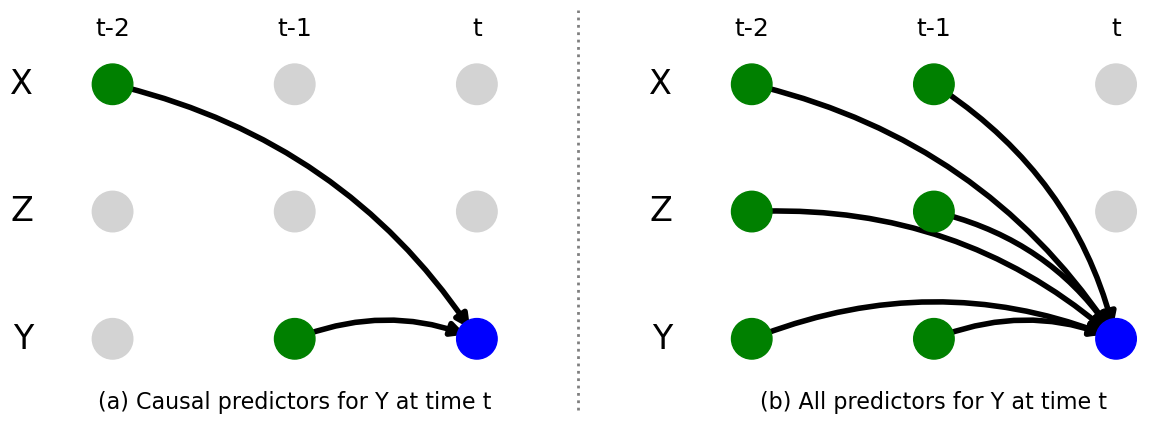

In [69]:


# Prepare data
np.random.seed(0)
df_train = pd.DataFrame(np.random.randn(100, 3), columns=['X', 'Z', 'Y'])
n_vars = 3
var_names = df_train.columns.tolist()

# First graph: only from X t-1 and Y t-1 to Y
data_simple = {
    2: [(0, -2), (2, -1)],
    0: [],
    1: []
}

# Second graph: complete, all-to-all, lags -1 and -2
data = {}
for target in range(n_vars):
    connections = []
    for source in range(n_vars):
        for lag in [-1, -2]:
            connections.append((source, lag))
    data[target] = connections

# ---- SIDE BY SIDE PLOTTING ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # wider

# Plot to axes[0]
plot_incoming_arrows(
    data_simple,
    target_variable=2,
    var_names=var_names,
    node_size=850,
    node_color='lightgrey',
    target_node_color='blue',
    highlight_color='green',
    arrow_color='black',
    arrow_size=20,
    title='(a) Causal',
    ax=axes[0]
)
# Plot to axes[1]
plot_incoming_arrows(
    data,
    target_variable=2,
    var_names=var_names,
    node_size=850,
    node_color='lightgrey',
    target_node_color='blue',
    highlight_color='green',
    arrow_color='black',
    arrow_size=20,
    title='(b) All',
    ax=axes[1]
)

plt.subplots_adjust(wspace=0.45)  # More space between subplots

# Add vertical line in figure coordinates at x=0.5 (center between the two subplots)
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.45)
fig_width, fig_height = fig.get_size_inches()
vline_x = 0.47  # halfway in figure-coordinates

fig.add_artist(plt.Line2D([vline_x, vline_x], [0.00, 1], color='black', linewidth=2, transform=fig.transFigure, alpha=0.5, linestyle=':'))

#fig.tight_layout()


figure_filename = os.path.join(folder_path, 'predictions_time_series_graph' + save_type)
plt.savefig(figure_filename, bbox_inches='tight', pad_inches=0.2, dpi=dpi)

fig.show()